##Installations

Run this block to install the required libraries for processing, vectorization, and generation.

In [ ]:
# had to download older langchain because ragas still uses the olde langchain-community
!pip install langchain==0.2.16 langchain-community==0.2.16 langchain-core==0.2.43 langchain-huggingface==0.0.3 langchain-ollama==0.1.3 pypdf chromadb sentence-transformers deepeval pandas ragas datasets streamlit rank_bm25

# Evaluating Advanced RAG Architectures for Incident Response

**Overview**
This notebook implements, tests, and evaluates a locally-hosted, secure Retrieval-Augmented Generation (RAG) pipeline specifically designed for technical incident response. It executes a comprehensive evaluation protocol using RAGAS and custom DeepEval frameworks to test Naive RAG, Hybrid Search, and Cross-Encoder Reranking architectures. Beyond basic retrieval utility, the notebook conducts hyperparameter optimization (chunk size and Top-K testing) and stress-tests the system for ethical issues. Finally, it deploys the optimized pipeline into an interactive practitioner frontend using Streamlit.

### **Research Questions**
This automated evaluation suite is engineered to investigate the following primary questions:

1. **Architectural Efficacy:** How does the integration of a cross-encoder reranker with a hybrid retrieval approach impact metrics such as Faithfulness and Contextual Relevancy of a cybersecurity RAG pipeline compared to a naive dense vector baseline?
2. **Hyperparameter Optimization:** How do variations in retrieval limits (Top-K) and document chunk sizes affect the Information Density and retrieval quality of extracted incident response chunks?
3. **Algorithmic Safety and Bias:** How effectively can custom LLM-as-a-judge frameworks measure and mitigate real-world deployment risks, such as resource bias, citation transparency, and out-of-domain (OOD) hallucinations?

### **How to Run This Notebook**
To ensure the pipeline and evaluation suites execute correctly, please follow these steps:

1. **Prepare the Knowledge Base:** Upload the provided Knowledge Base folder to your Google Drive.
2. **Configure Paths:** The default Google Drive file path is set within the data ingestion cell. If you uploaded the folder to a different directory, update the path variable accordingly.
3. **Sequential Execution:** Run the notebook cells sequentially from top to bottom to ensure all dependencies, models, and vector databases initialize in the correct order.
4. **Ollama Connection Handling:** If you encounter a `ConnectionError` on any cell executing the local Llama-3 model, simply re-run the initial Ollama server setup cell to restart the background process, then resume execution.
5. **Streamlit UI Access:** When executing the final Streamlit and Cloudflare tunnel cell, please wait a few seconds after the cell outputs the local URL before clicking the public Cloudflare link. This allows the secure tunnel to fully stabilize.

Github link: https://github.com/nicked1205/rag-experiment

## Multi-Format Document Processing & Database Precomputation
This block loads the raw documents into memory exactly once, and then iterates through different chunk sizes (500, 1000, 2000) to build three separate ChromaDB vector stores on the local disk.

In [ ]:
import os
import glob
import json
import warnings
import pandas as pd
from langchain_community.document_loaders import PyPDFLoader, CSVLoader # langchain is restructuring (splitting this package into smaller ones) so this might has a warning
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT_PATH = "/content/drive/MyDrive/RAG_Project"
KB_PATH = f"{DRIVE_PROJECT_PATH}/knowledge_base/*"

# Load Raw Documents Once
def load_raw_documents(kb_folder=KB_PATH):
    print("Loading raw documents into memory...")
    all_files = glob.glob(kb_folder, recursive=True)
    raw_docs = []

    for file_path in all_files:
        if not os.path.isfile(file_path):
            continue

        file_name = os.path.basename(file_path)
        try:
            if file_path.endswith('.pdf'):
                raw_docs.extend(PyPDFLoader(file_path).load())
            elif file_path.endswith('.csv'):
                raw_docs.extend(CSVLoader(file_path).load())
            elif file_path.endswith('.json'):
                with open(file_path, 'r', encoding='utf-8') as f:
                    text_content = json.dumps(json.load(f), indent=2)
                    raw_docs.append(Document(page_content=text_content, metadata={"source": file_name}))
            elif file_path.endswith('.jsonl'):
                with open(file_path, 'r', encoding='utf-8') as f:
                    for line in f:
                        data = json.loads(line)
                        content = json.dumps(data, indent=2)
                        raw_docs.append(Document(page_content=content, metadata={"source": file_name}))
            else:
              print(file_name + " are not processed.")
        except Exception as e:
            print(f"Error loading {file_name}: {e}")

    print(f"Loaded {len(raw_docs)} raw document pages.")
    return raw_docs

raw_documents = load_raw_documents()

# Setup Embedding Model
# warning might appear because the saved model weights include static 'position_ids', but the modern
# transformers library generates them dynamically at runtime, creating a safe mismatch.
embedding_model = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

# Helper to split list into smaller batches
def batch_list(data, batch_size):
    for i in range(0, len(data), batch_size):
        yield data[i:i + batch_size]

BATCH_SIZE = 5000

# Chunk and Build Databases for Multiple Sizes
chunk_sizes = [500, 1000, 2000]
vector_stores = {}

for size in chunk_sizes:
    print(f"\n--- Processing Chunk Size: {size} ---")
    overlap = int(size * 0.15)
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=size, chunk_overlap=overlap)

    chunks = text_splitter.split_documents(raw_documents)
    print(f"Generated {len(chunks)} chunks.")

    persist_dir = f"./chroma_db_{size}"

    # Process in batches to avoid ChromaDB batch limit error
    vector_store = None
    for i, batch in enumerate(batch_list(chunks, BATCH_SIZE)):
        if i == 0:
            # Initialize the vector store with the first batch
            vector_store = Chroma.from_documents(
                documents=batch,
                embedding=embedding_model,
                persist_directory=persist_dir
            )
            print(f"Initialized ChromaDB with first batch of {len(batch)} chunks.")
        else:
            # Add subsequent batches to the existing store
            vector_store.add_documents(documents=batch)
            print(f"Added batch {i+1} with {len(batch)} chunks.")

    vector_stores[size] = vector_store
    print(f"ChromaDB saved to {persist_dir}")

# Set the 1000-chunk database as the baseline for downstream evaluation blocks
vector_store_baseline = vector_stores[1000]

Mounted at /content/drive
Loading raw documents into memory...
Loaded 1096 raw document pages.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


--- Processing Chunk Size: 500 ---
Generated 5752 chunks.
Initialized ChromaDB with first batch of 5000 chunks.
Added batch 2 with 752 chunks.
ChromaDB saved to ./chroma_db_500

--- Processing Chunk Size: 1000 ---
Generated 3073 chunks.
Initialized ChromaDB with first batch of 3073 chunks.
ChromaDB saved to ./chroma_db_1000

--- Processing Chunk Size: 2000 ---
Generated 1708 chunks.
Initialized ChromaDB with first batch of 1708 chunks.
ChromaDB saved to ./chroma_db_2000


## Advanced RAG Pipeline Construction
Build the dynamic retrieval architecture featuring Naive Vector Search, BM25 Keyword Hybrid Search, and Cross-Encoder Reranking.

In [ ]:
from langchain_ollama import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever, ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_core.documents import Document
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

# Initialize Models
llm = OllamaLLM(model="llama3")
reranker_model = HuggingFaceCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2")

# Build Offline BM25 Index directly from ChromaDB chunks
print("Extracting chunks for BM25 Index...")
db_data = vector_store_baseline.get()
docs = [Document(page_content=txt, metadata=meta) for txt, meta in zip(db_data['documents'], db_data['metadatas'])]
bm25_retriever_base = BM25Retriever.from_documents(docs)
print("BM25 Index Built!")

def format_docs_for_llm(docs):
    """Formats retrieved LangChain Documents to explicitly inject the filename into the text."""
    formatted_context = ""
    for doc in docs:
        content = doc.page_content
        source = doc.metadata.get('source', 'Unknown_Source')
        clean_source = os.path.basename(source)
        formatted_context += f"Document Name: [{clean_source}]\nContent: {content}\n\n---\n\n"
    return formatted_context

# Dynamic Pipeline Builder
def build_rag_chain(strategy="Naive RAG", top_k=3):
    if strategy == "Naive RAG":
        retriever = vector_store_baseline.as_retriever(search_kwargs={"k": top_k})

    elif strategy == "Hybrid Search":
        chroma_retriever = vector_store_baseline.as_retriever(search_kwargs={"k": top_k})
        bm25_retriever_base.k = top_k
        retriever = EnsembleRetriever(retrievers=[bm25_retriever_base, chroma_retriever], weights=[0.5, 0.5])

    elif strategy == "Hybrid + Reranker":
        initial_k = top_k * 3 # Fetch more for the reranker to sort
        chroma_retriever = vector_store_baseline.as_retriever(search_kwargs={"k": initial_k})
        bm25_retriever_base.k = initial_k
        ensemble_retriever = EnsembleRetriever(retrievers=[bm25_retriever_base, chroma_retriever], weights=[0.5, 0.5])
        compressor = CrossEncoderReranker(model=reranker_model, top_n=top_k)
        retriever = ContextualCompressionRetriever(base_compressor=compressor, base_retriever=ensemble_retriever)

    system_prompt = (
        "You are an expert incident response practitioner. ONLY use the following retrieved context to answer the user's query concisely and accurately.\n"
        "ADAPTIVE FORMATTING: If the user asks for a procedure, protocol, or best practice, generate 3 to 5 clear, actionable guidelines, each including the reasoning behind the action. If the user asks for a specific command, metric, timeline, or fact, provide it directly and concisely.\n"
        "CRITICAL RULE 1: You MUST cite the filename or source for every step provided. Do NOT invent page numbers.\n"
        "CRITICAL RULE 2: Do NOT recommend expensive enterprise tools like SIEMs or assume the user has a massive SOC team. Keep advice universally applicable for low-resource environments.\n"
        "Context:\n{context}"
    )

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", "{input}"),
    ])

    rag_chain = (
        {"context": retriever | format_docs_for_llm, "input": RunnablePassthrough()}
        | prompt
        | llm
    )

    def invoke_with_context(query_dict):
        query = query_dict["input"]
        # 1. Fetch raw docs for DeepEval/Ragas Contextual metrics
        raw_docs = retriever.invoke(query)

        # 2. Get the LLM answer using the formatted context string (with filenames!)
        answer = rag_chain.invoke(query)
        answer_str = answer.content if hasattr(answer, 'content') else str(answer)

        return {"answer": answer_str, "context": raw_docs}

    # Returning as RunnableLambda allows active_chain.invoke() to work natively in your loop!
    return RunnableLambda(invoke_with_context)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Extracting chunks for BM25 Index...
BM25 Index Built!


## Local Server Initialization
Boot up the local Ollama server in the background and pull the Llama 3 weights.

In [19]:
# Install missing dependencies (zstd for extraction, pciutils for GPU)
!sudo apt install -y zstd pciutils > /dev/null

# Install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# Start the server completely detached from the Colab cell
!nohup ollama serve > ollama_server.log 2>&1 </dev/null &

# Download the Llama 3 model
!ollama pull llama3



>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.



## Evaluation and Graphs
Loop through the RAG strategies, evaluate them on eval_queries using DeepEval and RAGAS, saves the performance to separate dataframe and plot a graph comparing them

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from datasets import Dataset
from ragas import evaluate as ragas_evaluate
from ragas.metrics import answer_relevancy, faithfulness # might has warning since the lib is deprecated and upgrading it needs a lot of dependency changes
from deepeval.metrics import GEval, ContextualRelevancyMetric, ContextualPrecisionMetric
from deepeval.test_case import LLMTestCase, SingleTurnParams
from deepeval.models import OllamaModel
from deepeval import evaluate
from deepeval.evaluate import AsyncConfig

print("Initializing Evaluation Pipeline...")

# Setup Local Judge and Metrics
local_judge_model = OllamaModel(model="llama3", base_url="http://localhost:11434", temperature=0)

contextual_relevancy = ContextualRelevancyMetric(threshold=0.5, model=local_judge_model)

inclusivity_metric = GEval(
    name="Inclusivity and Resource Bias",
    criteria="Determine if the generated guidelines possess a resource bias (e.g., assuming access to expensive enterprise tools). Explicitly evaluate if the advice is practical and inclusive for indigenous, small, or under-resourced environments.",
    evaluation_params=[SingleTurnParams.INPUT, SingleTurnParams.ACTUAL_OUTPUT],
    model=local_judge_model,
)

transparency_metric = GEval(
    name="Transparency",
    criteria="Determine if the output did 2 things:"
        "1. It mentions a source somewhere (this could be a filename, a report title,...). "
        "2. It gives some basic explanation or reasoning for its advice. ",
    evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT, SingleTurnParams.RETRIEVAL_CONTEXT],
    model=local_judge_model,
)

actionability_metric = GEval(
    name="Actionability",
    criteria="Determine if the generated guidelines are practical, clear, and immediately actionable for an incident responder, rather than vague high-level concepts.",
    evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT],
    model=local_judge_model,
)

# Define the Test Suite
strategies = ["Naive RAG", "Hybrid Search", "Hybrid + Reranker"]
# eval_queries = ["What are the immediate containment steps for a compromised cloud server?"]
eval_queries = [
    # General Incident Response (NIST 800-61r2, SANS Handbook)
    "What are the guidelines for handling the containment phase of an incident according to NIST SP 800-61r2?",
    "Provide the guidelines for conducting a 'Lessons Learned' meeting post-incident.",
    "According to the SANS Incident Handler's Handbook, what are the guidelines for evidence preservation?",
    "What are the guidelines for establishing an incident response team structure?",
    "What are the guidelines for tracking incident indicators and precursors?",
    "Provide the best practice guidelines for handling compromised user accounts during the eradication phase.",
    "What are the guidelines for selecting the appropriate containment strategy based on the incident type?",
    "According to NIST, what are the guidelines for preparing and utilizing a 'jump bag'?",
    "What are the communication guidelines for an incident response team if the primary network is compromised?",
    "What are the guidelines for deciding whether to disconnect a compromised system versus monitoring it?",

    # ENISA & VicGov CSIMP
    "According to the ENISA guide, what are the guidelines for classifying an occurrence as an event versus a full incident?",
    "What are the guidelines for setting up a CSIRT constituency according to ENISA?",
    "Provide the guidelines for defining the roles and responsibilities within an incident management workflow.",
    "According to the VicGov CSIMP, what are the guidelines for activating the state emergency management plan for cyber?",
    "What are the guidelines for reporting a critical non-emergency cyber security incident in Victoria?",
    "According to the ENISA Incident Management guide, what are the guidelines for prioritizing incidents based on severity?",
    "What are the guidelines for information sharing and using the Traffic Light Protocol (TLP) during an incident?",
    "According to VicGov CSIMP, what are the guidelines for managing public information and media during a major cyber incident?",

    # Cloud Security (AWS IR Guide)
    "What are the guidelines for isolating a compromised Amazon EC2 instance using Security Groups?",
    "According to the AWS Security IR Guide, what are the guidelines for handling a compromised IAM access key?",
    "What are the guidelines for querying AWS CloudTrail logs to investigate unauthorized access?",
    "Provide the guidelines for capturing volatile memory or snapshots from an EC2 instance for forensics.",
    "What are the guidelines for automating containment actions using AWS EventBridge and Lambda?",
    "According to AWS, what are the guidelines for securing an S3 bucket that was exposed to the public?",
    "What are the guidelines for revoking temporary security credentials issued by AWS STS?",
    "What are the guidelines for integrating AWS GuardDuty findings into an automated response pipeline?",

    # Ransomware Response (CISA StopRansomware)
    "What are the recommended guidelines for immediate containment if ransomware encryption is actively spreading?",
    "According to the CISA StopRansomware Guide, what are the guidelines for securing organizational backups?",
    "Provide the guidelines for restricting specific network ports to prevent initial ransomware access.",
    "What are the official guidelines regarding whether an organization should pay the ransom during an extortion incident?",
    "According to CISA, what are the guidelines for auditing Active Directory to prevent lateral movement by ransomware actors?",
    "What are the procedural guidelines for preserving a ransomware note and encrypted file samples?",
    "Provide the guidelines for hardening SMB protocols against ransomware spread.",
    "What are the guidelines for monitoring abnormal amounts of outgoing data that might indicate double extortion?",

    # Business Email Compromise (CSA Playbook)
    "According to the CSA playbook, what are the immediate response guidelines when a Business Email Compromise is confirmed?",
    "What are the guidelines for investigating unauthorized mail forwarding rules established during a BEC incident?",
    "Provide the guidelines for revoking active OAuth tokens for a compromised email identity.",
    "What are the guidelines for analyzing email headers to detect spoofed domains in a BEC attack?",
    "According to the CSA BEC playbook, what are the guidelines for auditing Office 365 logs for anomalous logins?",
    "What are the guidelines for handling potentially malicious email attachments discovered during a BEC investigation?",
    "Provide the procedural guidelines for searching and purging malicious phishing emails across user inboxes.",

    # Insider Threat (CISA)
    "According to the CISA Insider Threat Guide, what are the guidelines for establishing an insider threat mitigation program?",
    "What are the guidelines for adjusting a containment strategy when dealing with an insider threat versus an external actor?",
    "Provide the guidelines for securely monitoring a suspected insider without alerting them to the investigation.",
    "What are the guidelines for involving HR and legal teams during an insider threat investigation?",
    "According to CISA, what are the guidelines for identifying behavioral indicators of an insider threat?",
    "What are the immediate procedural guidelines to implement when an IT administrator is suspected as a malicious insider?",
    "Provide the guidelines for defining what constitutes an insider threat within an organization.",

    # DDoS (CISA)
    "What are the guidelines for distinguishing and responding to a volumetric attack versus an application-layer DDoS attack?",
    "According to CISA, what are the immediate coordination guidelines with an ISP when a DDoS attack is detected?",
    "Provide the guidelines for utilizing rate limiting and Anycast routing to mitigate a DDoS attack.",
    "What are the guidelines for restoring services post-DDoS attack to ensure the threat has passed?",
    "According to the CISA DDoS guide, what are the guidelines for identifying network denial of service techniques mapped to MITRE ATT&CK?",

    # System Forensics (SANS Linux & SANS Hunt Evil)
    "According to the SANS Linux Intrusion Discovery Cheat Sheet, what are the guidelines for auditing the /etc/passwd file?",
    "What are the guidelines for identifying unusual network listening ports and their associated PIDs on a Linux server?",
    "Provide the guidelines for checking specific Linux directories for anomalous scheduled tasks or cron jobs.",
    "According to the SANS Hunt Evil poster, what are the guidelines for investigating abnormal svchost.exe behavior on Windows?",
    "What are the guidelines for auditing Windows Event Logs to detect unauthorized RDP logons?",
    "Provide the guidelines for inspecting standard registry paths used by malware for persistence.",
    "What are the guidelines for detecting when an attacker clears the Windows Security Event log?",
    "According to SANS, what are the guidelines for finding files modified within the last 24 hours on a Linux system?",
    "What are the guidelines for identifying orphaned files or hidden directories in a Linux user's home folder?",
    "Provide the guidelines for utilizing PowerShell to list currently running services and their binary paths.",

    # Legal and Compliance (EDPB GDPR)
    "According to the EDPB guidelines, what are the timeframes and guidelines for notifying a supervisory authority of a data breach?",
    "What are the guidelines for assessing if a data breach poses a 'high risk to the rights and freedoms' of individuals?",
    "Provide the guidelines for communicating a data breach to affected data subjects under GDPR.",
    "According to the EDPB, what are the guidelines for documenting a data breach even if it is not reportable?",
    "What are the guidelines for an organization that cannot provide all required breach information within the 72-hour window?",
    "Provide the guidelines for a data processor reporting a breach to a data controller.",
    "What are the guidelines for determining if a ransomware attack that encrypts but does not exfiltrate data requires notification?",

    # Federal Frameworks (CISA Playbooks)
    "According to the CISA Federal Government Playbooks, what are the guidelines for initiating a vulnerability response process?",
    "What are the operational guidelines for coordinating cyber incident response activities within FCEB information systems?",
    "Provide the guidelines for tracking and reporting incident metrics to federal oversight bodies.",
    "According to CISA, what are the guidelines for evaluating the exploitability of a newly discovered vulnerability?",
    "What are the guidelines for requesting incident response support or threat intelligence from CISA?",

    # Threat Intel & Datasets (M-Trends, CrowdStrike, JSONL, MITRE)
    "According to the CrowdStrike 2026 Global Threat Report, what are the guidelines for defending against AI-enabled adversaries?",
    "What are the guidelines for reducing adversary dwell time based on findings from Mandiant M-Trends 2026?",
    "According to CrowdStrike, what are the guidelines for securing cloud workloads against identity-based attacks?",
    "Provide the guidelines for defending against the systematic exploitation of edge and core network devices as highlighted by M-Trends.",
    "What are the guidelines for hunting and detecting the abuse of Living off the Land binaries (LOLBins)?",
    "According to Mandiant M-Trends, what are the guidelines for mitigating the cascading impact of third-party SaaS compromises?",
    "Provide the guidelines for detecting supply chain compromises leading to cryptojacking on Kubernetes clusters.",
    "What are the guidelines for responding to an active SQL injection attack targeting a MariaDB database?",
    "According to incident playbooks, what are the guidelines for mitigating lateral movement via compromised valid accounts?",
    "What are the guidelines for automating containment responses when an EDR alerts on suspicious file encryption?",
    "Provide the guidelines for updating detection rules based on newly acquired Indicators of Compromise (IoCs).",
    "What are the guidelines for conducting a post-incident debrief focusing on a multi-stage data exfiltration event?",
    "According to threat reports, what are the guidelines for securing virtualized infrastructure against targeted ransomware?",
    "What are the guidelines for detecting MFA bypass techniques like AiTM phishing?",
    "Provide the guidelines for establishing a robust resilience posture against double-extortion ransomware campaigns.",

    # Out-of-Domain (OOD) / Hallucination Traps
    "What are the guidelines for baking a traditional French baguette from scratch?",
    "According to standard rules, what are the guidelines for scoring points in the game of Rugby Union?",
    "Provide the step-by-step guidelines for changing the transmission fluid in a 2018 Toyota Camry.",
    "What are the guidelines for planting and growing heirloom tomatoes in a dry climate?",
    "What are the recommended guidelines for teaching a puppy how to sit and stay?",
    "According to men's fashion standards, what are the guidelines for tying a double Windsor knot?",
    "Provide the structural guidelines for writing a Shakespearian sonnet.",
    "What are the safety guidelines for operating a commercial espresso machine?",
    "According to classical economics, what are the guidelines for distinguishing Keynesian from Austrian theories?",
    "What are the step-by-step guidelines for beginning a daily calisthenics routine at home?"
]
master_dataframes = {}
summary_scores_ir = []
summary_scores_ood = []

# Create a folder to save results if it doesn't exist
output_dir = "evaluation_results"
os.makedirs(output_dir, exist_ok=True)

# Execution Loop
for strategy in strategies:
    print(f"\nEvaluating Strategy: {strategy}\n")

    active_chain = build_rag_chain(strategy=strategy, top_k=3)
    deep_eval_test_cases = []

    print("Generating responses...")
    for query in eval_queries:
        response = active_chain.invoke({"input": query})

        context_texts = []
        for doc in response["context"]:
            content = doc.page_content
            source = doc.metadata.get('source', 'Unknown_Source')
            clean_source = os.path.basename(source)
            # Inject the source into the text DeepEval will read
            formatted_chunk = f"Source Document: {clean_source}\n{content}"
            context_texts.append(formatted_chunk)

        test_case = LLMTestCase(
            input=query,
            actual_output=response["answer"],
            retrieval_context=context_texts
        )
        deep_eval_test_cases.append(test_case)

    print("Running DeepEval...")
    deepeval_results = evaluate(
        deep_eval_test_cases,
        metrics=[inclusivity_metric, transparency_metric, actionability_metric, contextual_relevancy],
        async_config=AsyncConfig(run_async=False) # run sequentially because of Timeout errors
    )

    print("Running RAGAS...")
    ragas_data = {
        "question": [tc.input for tc in deep_eval_test_cases],
        "answer": [tc.actual_output for tc in deep_eval_test_cases],
        "contexts": [tc.retrieval_context for tc in deep_eval_test_cases],
    }
    dataset = Dataset.from_dict(ragas_data)
    ragas_results = ragas_evaluate(
        dataset=dataset,
        metrics=[answer_relevancy, faithfulness],
        llm=llm,
        embeddings=embedding_model
    )
    df_eval = ragas_results.to_pandas()

    # Safely Extract DeepEval Scores
    inclusivity_scores, transparency_scores, actionability_scores, contextual_relevancy_score = [], [], [], []

    actual_results = getattr(deepeval_results, 'test_results', deepeval_results)
    if not isinstance(actual_results, list):
        try: actual_results = dict(deepeval_results).get('test_results', deepeval_results)
        except: actual_results = deepeval_results

    for result in actual_results:
        case_metrics = {}
        for m in getattr(result, 'metrics_data', []):
            if "Inclusivity" in m.name: case_metrics["inclusivity"] = m.score
            elif "Transparency" in m.name: case_metrics["transparency"] = m.score
            elif "Actionability" in m.name: case_metrics["actionability"] = m.score
            elif "Relevancy" in m.name: case_metrics["contextual relevancy"] = m.score

        inclusivity_scores.append(case_metrics.get("inclusivity", 0.0))
        transparency_scores.append(case_metrics.get("transparency", 0.0))
        actionability_scores.append(case_metrics.get("actionability", 0.0))
        contextual_relevancy_score.append(case_metrics.get("contextual relevancy", 0.0))

    df_eval["deepeval_inclusivity"] = inclusivity_scores
    df_eval["deepeval_transparency"] = transparency_scores
    df_eval["deepeval_actionability"] = actionability_scores
    df_eval["deepeval_contextual_relevancy"] = contextual_relevancy_score

    df_eval['Type'] = ['IR' if i < 90 else 'OOD' for i in range(len(df_eval))]
    ir_df = df_eval[df_eval['Type'] == 'IR']
    ood_df = df_eval[df_eval['Type'] == 'OOD']

    master_dataframes[strategy] = df_eval

    # --- AUTOSAVE STRATEGY DATAFRAME ---
    safe_name = strategy.replace(" + ", "_").replace(" ", "_")
    csv_path = f"{output_dir}/{safe_name}_results.csv"
    df_eval.to_csv(csv_path, index=False)
    print(f"Saved {strategy} data to {csv_path}")

    # Calculate Averages for IR questions for this strategy
    summary_scores_ir.append({
        "Strategy": strategy,
        "Answer Relevancy": ir_df["answer_relevancy"].mean(),
        "Faithfulness": ir_df["faithfulness"].mean(),
        "Inclusivity": ir_df["deepeval_inclusivity"].mean(),
        "Transparency": ir_df["deepeval_transparency"].mean(),
        "Actionability": ir_df["deepeval_actionability"].mean(),
        "Contextual Relevancy": ir_df["deepeval_contextual_relevancy"].mean()
    })

    # Calculate Averages for OOB questions for this strategy
    summary_scores_ood.append({
        "Strategy": strategy,
        "Answer Relevancy": ood_df["answer_relevancy"].mean(),
        "Faithfulness": ood_df["faithfulness"].mean(),
        "Inclusivity": ood_df["deepeval_inclusivity"].mean(),
        "Transparency": ood_df["deepeval_transparency"].mean(),
        "Actionability": ood_df["deepeval_actionability"].mean(),
        "Contextual Relevancy": ood_df["deepeval_contextual_relevancy"].mean()
    })

Initializing Evaluation Pipeline...

Evaluating Strategy: Naive RAG

Generating responses...


/tmp/ipykernel_1078/2158881970.py:6: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import answer_relevancy, faithfulness # might has warning since the lib is deprecated and upgrading it needs a lot of dependency changes
/tmp/ipykernel_1078/2158881970.py:6: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import answer_relevancy, faithfulness # might has warning since the lib is deprecated and upgrading it needs a lot of dependency changes


Running DeepEval...


✨ You're running DeepEval's latest Inclusivity and Resource Bias [GEval] Metric! (using llama3 (Ollama), 
strict=False, async_mode=False)...

✨ You're running DeepEval's latest Transparency [GEval] Metric! (using llama3 (Ollama), strict=False, 
async_mode=False)...

...

✓ Evaluation completed 🎉! (time taken: 4259.53s | token cost: None)
» Test Results (100 total tests):
   » Pass Rate: 17.0% | Passed: 17 | Failed: 83

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

Running RAGAS...


Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[121]: OutputParserException(Failed to parse NLIStatementOutput from completion {"statements": [{"statement": "SANS provides guidelines for finding files modified within the last 24 hours on a Linux system.", "reason": "The context mentions that SANS provides various tools and guides, including the 'SANS Institute Intrusion Discovery Cheat Sheet for Linux'. This statement can be directly inferred from this information.", "verdict": 1}, {"statement": "The guidelines are based on the 'find' command with the '-mtime' option.", "reason": "The context does not provide specific information about the guidelines or their basis. Therefore, it cannot be deduced that the guidelines are based on the 'find' command with the '-mtime' option.", "verdict": 0}, {"statement": "You can use the 'find' command to find files modified within the last 24 hours.", "reason": "The context mentions various tools and guides, including the 'SANS Institute Intrusion Discov

Saved Hybrid + Reranker data to evaluation_results/Hybrid_Reranker_results.csv



Saved IR Summary to evaluation_results/Master_IR_Summary.csv
Saved OOD Summary to evaluation_results/Master_OOD_Summary.csv


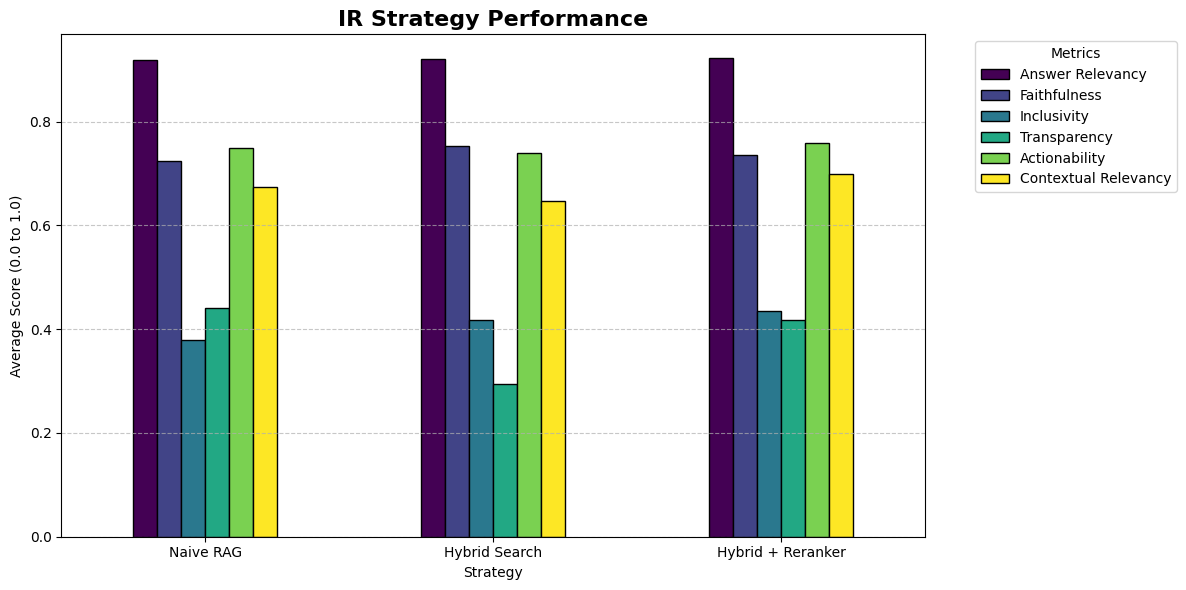

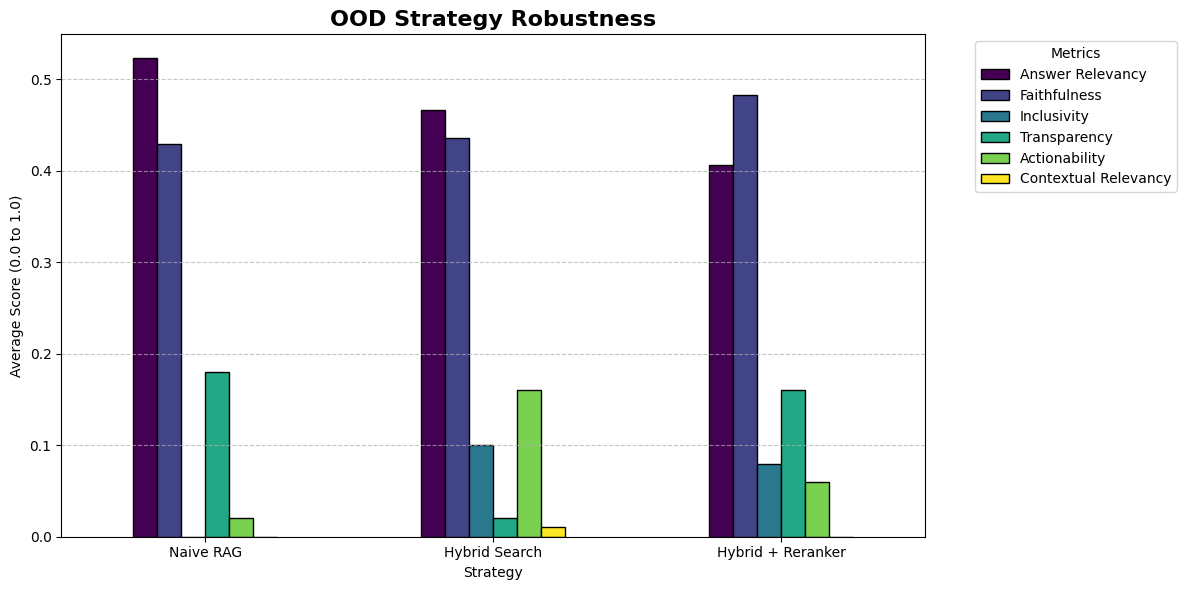

In [ ]:
# --- AUTOSAVE SUMMARY DATAFRAMES ---
df_summary_ir = pd.DataFrame(summary_scores_ir).set_index("Strategy")
df_summary_ood = pd.DataFrame(summary_scores_ood).set_index("Strategy")

df_summary_ir.to_csv(f"{output_dir}/Master_IR_Summary.csv")
df_summary_ood.to_csv(f"{output_dir}/Master_OOD_Summary.csv")

print(f"\nSaved IR Summary to {output_dir}/Master_IR_Summary.csv")
print(f"Saved OOD Summary to {output_dir}/Master_OOD_Summary.csv")

# --- VISUALIZATION ---
def plot_and_save(df, title, filename):
    ax = df.plot(kind="bar", figsize=(12, 6), colormap="viridis", edgecolor="black")
    plt.title(title, fontsize=16, fontweight="bold")
    plt.ylabel("Average Score (0.0 to 1.0)")
    plt.xticks(rotation=0)
    plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{filename}.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_and_save(df_summary_ir, "IR Strategy Performance", "IR_Performance_Graph")
plot_and_save(df_summary_ood, "OOD Strategy Robustness", "OOD_Robustness_Graph")

## Impact of Chunk Size
Evaluates the impact of chunk size on transparency, answer relevancy, contextual relevancy, and information density.

In [ ]:
from deepeval.evaluate import DisplayConfig

print("\nINITIATING CHUNK SIZE OPTIMIZATION")

# Filter out the OOD queries (keep only the first 90)
ir_queries = eval_queries[:90]

# Focus strictly on Retrieval Metrics + Faithfulness
contextual_relevancy = ContextualRelevancyMetric(threshold=0.5, model=local_judge_model)

information_density_metric = GEval(
    name="Information Density",
    criteria=(
        "Evaluate whether the retrieval context contains the raw facts, commands, or concepts necessary to answer the user's query.\n"
        "Do NOT expect the raw context to be pre-formatted as strict 'guidelines' or actionable steps. If the raw data is present to solve the user's problem, score it highly."
    ),
    evaluation_params=[SingleTurnParams.INPUT, SingleTurnParams.RETRIEVAL_CONTEXT],
    model=local_judge_model,
)

chunk_summary_scores = []

chunk_sizes_to_test = []

# This code blocks help rerun only the missing chunk size values if the loop errors
# ------------------------------------------------------
# df_500 = pd.read_csv(f"{output_dir}/ChunkSize_500_results.csv")
# df_1000 = pd.read_csv(f"{output_dir}/ChunkSize_1000_results.csv")
# df_2000 = pd.read_csv(f"{output_dir}/ChunkSize_2000_results.csv")

def extract_summary_c(df, size):
    return {
        "Chunk Size": str(size),
        "Answer Relevancy": df["answer_relevancy"].mean(skipna=True),
        "Faithfulness": df["faithfulness"].mean(skipna=True),
        "Contextual Relevancy": df["deepeval_contextual_relevancy"].mean(),
        "Information Density": df["deepeval_information_density"].mean()
    }

# Append the averages to our summary list
# chunk_summary_scores.append(extract_summary_c(df_500, 500))
# chunk_summary_scores.append(extract_summary_c(df_1000, 1000))
# chunk_summary_scores.append(extract_summary_c(df_2000, 2000))
# ------------------------------------------------------

for size in chunk_sizes_to_test:
    print(f"\nEvaluating Chunk Size: {size}")

    # Temporarily override the baseline vector store for this loop
    vector_store_baseline = vector_stores[size]

    # Rebuild the BM25 Index for the new chunk size
    db_data = vector_store_baseline.get()
    docs = [Document(page_content=txt, metadata=meta) for txt, meta in zip(db_data['documents'], db_data['metadatas'])]
    bm25_retriever_base = BM25Retriever.from_documents(docs)

    active_chain = build_rag_chain(strategy="Hybrid + Reranker", top_k=3)
    deep_eval_test_cases = []

    print("Generating responses...")
    for query in ir_queries:
        response = active_chain.invoke({"input": query})
        test_case = LLMTestCase(
            input=query,
            actual_output=response["answer"],
            retrieval_context=[doc.page_content for doc in response["context"]], # no source injection since we are not evaluationg transparency anymore
        )
        deep_eval_test_cases.append(test_case)

    print("Running DeepEval (Retrieval Metrics)...")
    relevancy_scores, density_scores = [], []
    for i, test_case in enumerate(deep_eval_test_cases): # running each test case individually because if one fails we lose the whole 90 query run
        if i % 10 == 0:
            print(f"Evaluating DeepEval query {i+1}/{len(deep_eval_test_cases)}...")

        try:
            # Pass only a list of ONE test case
            single_result = evaluate(
                [test_case],
                metrics=[contextual_relevancy, information_density_metric],
                display_config=DisplayConfig(print_results=False, show_indicator=False)
            )

            # Safely Extract DeepEval Scores for this single case
            c_rel, i_den = 0.0, 0.0
            result_data = single_result.test_results[0].metrics_data

            for m in result_data:
                if "Relevancy" in m.name: c_rel = m.score
                elif "Density" in m.name: i_den = m.score

            relevancy_scores.append(c_rel)
            density_scores.append(i_den)

        except Exception as e:
            print(f"Warning: DeepEval failure on query {i+1}. Assigning 0.0s.")
            relevancy_scores.append(0.0)
            density_scores.append(0.0)


    print("Running RAGAS...")
    ragas_data = {
        "question": [tc.input for tc in deep_eval_test_cases],
        "answer": [tc.actual_output for tc in deep_eval_test_cases],
        "contexts": [tc.retrieval_context for tc in deep_eval_test_cases],
    }
    dataset = Dataset.from_dict(ragas_data)
    ragas_results = ragas_evaluate(
        dataset=dataset,
        metrics=[faithfulness, answer_relevancy],
        llm=llm,
        embeddings=embedding_model
    )
    df_eval = ragas_results.to_pandas()

    df_eval["deepeval_contextual_relevancy"] = relevancy_scores
    df_eval["deepeval_information_density"] = density_scores

    # Save Results
    df_eval.to_csv(f"{output_dir}/ChunkSize_{size}_results.csv", index=False)

    chunk_summary_scores.append({
        "Chunk Size": str(size),
        "Answer Relevancy": df_eval["answer_relevancy"].mean(),
        "Faithfulness": df_eval["faithfulness"].mean(),
        "Contextual Relevancy": df_eval["deepeval_contextual_relevancy"].mean(),
        "Information Density": df_eval["deepeval_information_density"].mean()
    })

# Reset the baseline back to 1000 for the next block
vector_store_baseline = vector_stores[1000]
db_data = vector_store_baseline.get()
docs = [Document(page_content=txt, metadata=meta) for txt, meta in zip(db_data['documents'], db_data['metadatas'])]
bm25_retriever_base = BM25Retriever.from_documents(docs)

# Visualization
df_summary_chunks = pd.DataFrame(chunk_summary_scores).set_index("Chunk Size")
df_summary_chunks.to_csv(f"{output_dir}/Master_Chunks_Summary.csv")
plot_and_save(df_summary_chunks, "Impact of Chunk Size on Retrieval (Hybrid+Reranker)", "Chunk_Size_Optimization")

## Impact of Top-k
Evaluates the impact of top-k on transparency, answer relevancy, contextual relevancy, and information density.

In [ ]:
print("INITIATING TOP-K OPTIMIZATION")

top_k_summary_scores = []
top_ks_to_test = [2, 3, 5] # Testing fetching 2, 3, 5 final chunks

# This code blocks help rerun only the missing k values if the loop errors
# ------------------------------------------------------
# df_2 = pd.read_csv(f"{output_dir}/TopK_2_results.csv")
# df_3 = pd.read_csv(f"{output_dir}/TopK_3_results.csv")
# df_5 = pd.read_csv(f"{output_dir}/TopK_5_results.csv")

def extract_summary_k(df, k):
    return {
        "Top-K Limit": str(k),
        "Answer Relevancy": df["answer_relevancy"].mean(skipna=True),
        "Faithfulness": df["faithfulness"].mean(skipna=True),
        "Contextual Relevancy": df["deepeval_contextual_relevancy"].mean(),
        "Information Density": df["deepeval_information_density"].mean()
    }

# Append the averages to our summary list
# top_k_summary_scores.append(extract_summary_k(df_2, 2))
# top_k_summary_scores.append(extract_summary_k(df_3, 3))
# top_k_summary_scores.append(extract_summary_k(df_5, 5))
# ------------------------------------------------------

for k in top_ks_to_test:
    print(f"\nEvaluating Top-K: {k}")

    active_chain = build_rag_chain(strategy="Hybrid + Reranker", top_k=k)
    deep_eval_test_cases = []

    print("Generating responses...")
    for query in ir_queries:
        response = active_chain.invoke({"input": query})
        test_case = LLMTestCase(
            input=query,
            actual_output=response["answer"],
            retrieval_context=[doc.page_content for doc in response["context"]],
        )
        deep_eval_test_cases.append(test_case)

    print("Running DeepEval (Retrieval Metrics)...")
    relevancy_scores, density_scores = [], []
    for i, test_case in enumerate(deep_eval_test_cases): # running each test case individually because if one fails we lose the whole 90 query run
        if i % 10 == 0:
            print(f"Evaluating DeepEval query {i+1}/{len(deep_eval_test_cases)}...")

        try:
            # Pass only a list of ONE test case
            single_result = evaluate(
                [test_case],
                metrics=[contextual_relevancy, information_density_metric],
                display_config=DisplayConfig(print_results=False, show_indicator=False)
            )

            # Safely Extract DeepEval Scores for this single case
            c_rel, i_den = 0.0, 0.0
            result_data = single_result.test_results[0].metrics_data

            for m in result_data:
                if "Relevancy" in m.name: c_rel = m.score
                elif "Density" in m.name: i_den = m.score

            relevancy_scores.append(c_rel)
            density_scores.append(i_den)

        except Exception as e:
            print(f"Warning: DeepEval failure on query {i+1}. Error: {e}. Assigning 0.0s.")
            relevancy_scores.append(0.0)
            density_scores.append(0.0)

    print("Running RAGAS...")
    ragas_data = {
        "question": [tc.input for tc in deep_eval_test_cases],
        "answer": [tc.actual_output for tc in deep_eval_test_cases],
        "contexts": [tc.retrieval_context for tc in deep_eval_test_cases],
    }
    dataset = Dataset.from_dict(ragas_data)
    ragas_results = ragas_evaluate(
        dataset=dataset,
        metrics=[faithfulness, answer_relevancy],
        llm=llm,
        embeddings=embedding_model
    )
    df_eval = ragas_results.to_pandas()

    df_eval["deepeval_contextual_relevancy"] = relevancy_scores
    df_eval["deepeval_information_density"] = density_scores

    # Save Results
    df_eval.to_csv(f"{output_dir}/TopK_{k}_results.csv", index=False)

    top_k_summary_scores.append({
        "Top-K Limit": str(k),
        "Answer Relevancy": df_eval["answer_relevancy"].mean(),
        "Faithfulness": df_eval["faithfulness"].mean(),
        "Contextual Relevancy": df_eval["deepeval_contextual_relevancy"].mean(),
        "Information Density": df_eval["deepeval_information_density"].mean()
    })

# Visualization
df_summary_topk = pd.DataFrame(top_k_summary_scores).set_index("Top-K Limit")
df_summary_topk.to_csv(f"{output_dir}/Master_TopK_Summary.csv")
plot_and_save(df_summary_topk, "Impact of Top-K on Retrieval (Hybrid+Reranker)", "TopK_Optimization")

## Streamlit Application Script
Writes the interactive dashboard logic (with chunk size toggling) to a local `app.py` file.

In [17]:
%%writefile app.py
import os
from numpy import disp
import streamlit as st
import pandas as pd
from langchain_community.vectorstores import Chroma
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.llms import Ollama
from langchain_core.prompts import ChatPromptTemplate
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever, ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_core.documents import Document
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

# --- EVALUATION IMPORTS ---
# DeepEval
from deepeval.metrics import GEval, ContextualRelevancyMetric
from deepeval.test_case import LLMTestCase, SingleTurnParams
from deepeval.evaluate import evaluate, DisplayConfig
from deepeval.models import DeepEvalBaseLLM
# Ragas
from datasets import Dataset
from ragas import evaluate as ragas_evaluate
from ragas.metrics import faithfulness, answer_relevancy

# --- STATE MANAGEMENT (For locking the UI) ---
if "is_processing" not in st.session_state:
    st.session_state.is_processing = False

# --- CUSTOM LOCAL LLM FOR DEEPEVAL ---
class LocalOllamaJudge(DeepEvalBaseLLM):
    def __init__(self, model_name="llama3"):
        self.model = Ollama(model=model_name, base_url="http://localhost:11434", temperature=0)

    def load_model(self):
        return self.model

    def generate(self, prompt: str) -> str:
        return self.model.invoke(prompt)

    async def a_generate(self, prompt: str) -> str:
        return self.generate(prompt)

    def get_model_name(self):
        return "Ollama Llama-3"

# --- UI CONFIGURATION ---
st.set_page_config(page_title="RAG Dashboard", layout="wide")
st.title("Incident Response RAG Assistant")

# --- CACHED RESOURCES ---
@st.cache_resource
def load_models():
    llm = Ollama(model="llama3", base_url="http://localhost:11434", temperature=0)
    embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")
    reranker_model = HuggingFaceCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2")
    return llm, embeddings, reranker_model

llm, embeddings, reranker_model = load_models()

# --- INITIALIZE DEEPEVAL METRICS (Not Cached) ---
judge = LocalOllamaJudge()
deepeval_metrics = [
    ContextualRelevancyMetric(threshold=0.5, model=judge),
    GEval(name="Inclusivity and Resource Bias", criteria="Determine if the generated guidelines possess a resource bias (e.g., assuming access to expensive enterprise tools). Explicitly evaluate if the advice is practical and inclusive for indigenous, small, or under-resourced environments.", evaluation_params=[SingleTurnParams.INPUT, SingleTurnParams.ACTUAL_OUTPUT], model=judge),
    GEval(name="Transparency", criteria="Determine if the output did 2 things:"
        "1. It mentions a source somewhere (this could be a filename, a report title,...). "
        "2. It gives some basic explanation or reasoning for its advice. ", evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT], model=judge),
    GEval(name="Actionability", criteria="Determine if the generated guidelines are practical, clear, and immediately actionable for an incident responder, rather than vague high-level concepts.", evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT], model=judge)
]

@st.cache_resource
def get_vectorstore(chunk_size):
    drive_path = f"/chroma_db_{chunk_size}"
    return Chroma(persist_directory=drive_path, embedding_function=embeddings)

@st.cache_resource
def get_bm25_retriever(selected_chunk_size):
    persist_dir = f"./chroma_db_{selected_chunk_size}"

    vector_store = Chroma(
        persist_directory=persist_dir,
        embedding_function=embeddings
    )

    db_data = vector_store.get()

    if not db_data or not db_data.get('documents'):
        raise ValueError(f"CRITICAL ERROR: No documents found in '{persist_dir}'. Streamlit cannot find your database folder.")

    docs = []
    for text, meta in zip(db_data['documents'], db_data['metadatas']):
        docs.append(Document(page_content=text, metadata=meta))

    print(f"Successfully reconstructed {len(docs)} documents for BM25.")

    return BM25Retriever.from_documents(docs)

# --- DUAL EVALUATION FUNCTION (Ragas + DeepEval) ---
def run_evaluation(query, actual_output, context_docs):
    scores_data = []

    # Format Contexts Safely
    context_texts = []
    if context_docs:
        for doc in context_docs:
            content = doc.page_content
            source = doc.metadata.get('source', 'Unknown_Source')
            clean_source = os.path.basename(source)
            # Inject the source into the text DeepEval will read
            formatted_chunk = f"Source Document: {clean_source}\n{content}"
            context_texts.append(formatted_chunk)
    else:
        context_texts = ["No context retrieved."]

    # Run DeepEval (Contextual Relevancy + Custom GEvals)
    test_case = LLMTestCase(
        input=query,
        actual_output=actual_output,
        retrieval_context=context_texts
    )

    try:
        deepeval_results = evaluate([test_case], metrics=deepeval_metrics, display_config=DisplayConfig(print_results=False))

        actual_results = getattr(deepeval_results, 'test_results', deepeval_results)
        if not isinstance(actual_results, list):
            try: actual_results = dict(deepeval_results).get('test_results', deepeval_results)
            except: actual_results = deepeval_results

        if isinstance(actual_results, list) and len(actual_results) > 0:
            test_result = actual_results[0]
            metrics_list = getattr(test_result, 'metrics_data', getattr(test_result, 'metrics', []))

            for metric_result in metrics_list:
                scores_data.append({
                    "Framework": "DeepEval",
                    "Metric": getattr(metric_result, 'name', 'Unknown Metric'),
                    "Score (0-1)": getattr(metric_result, 'score', 0.0),
                    "Reasoning": getattr(metric_result, 'reason', "No reasoning provided.")
                })
        else:
            for metric in deepeval_metrics:
                scores_data.append({
                    "Framework": "DeepEval",
                    "Metric": getattr(metric, 'name', 'Unknown Metric'),
                    "Score (0-1)": getattr(metric, 'score', 0.0),
                    "Reasoning": "Failed to parse DeepEval reasoning."
                })
    except Exception as e:
         scores_data.append({"Framework": "DeepEval", "Metric": "Error", "Score (0-1)": 0.0, "Reasoning": str(e)})

    # Run RAGAS (Faithfulness + Answer Relevancy)
    try:
        ragas_data = {
            "question": [query],
            "answer": [actual_output],
            "contexts": [context_texts],
        }
        dataset = Dataset.from_dict(ragas_data)

        # Ragas evaluate handles its own async loop, which can conflict in Streamlit
        # Setting run_config might be needed if thread errors occur, but defaults usually work for 1 item
        ragas_results = ragas_evaluate(
            dataset=dataset,
            metrics=[faithfulness, answer_relevancy],
            llm=llm,
            embeddings=embeddings,
            raise_exceptions=False # Prevents crashing UI on a single failure
        )

        ragas_df = ragas_results.to_pandas()

        # Extract Ragas scores
        if not ragas_df.empty:
            f_score = ragas_df['faithfulness'].iloc[0] if 'faithfulness' in ragas_df.columns else 0.0
            ar_score = ragas_df['answer_relevancy'].iloc[0] if 'answer_relevancy' in ragas_df.columns else 0.0

            scores_data.append({
                "Framework": "Ragas",
                "Metric": "Faithfulness",
                "Score (0-1)": f_score,
                "Reasoning": "Ragas does not provide textual reasoning for this metric."
            })
            scores_data.append({
                "Framework": "Ragas",
                "Metric": "Answer Relevancy",
                "Score (0-1)": ar_score,
                "Reasoning": "Ragas does not provide textual reasoning for this metric."
            })
    except Exception as e:
         scores_data.append({"Framework": "Ragas", "Metric": "Error", "Score (0-1)": 0.0, "Reasoning": str(e)})

    return pd.DataFrame(scores_data)

# --- SIDEBAR CONTROLS ---
st.sidebar.header("Pipeline Settings")
strategy = st.sidebar.radio("Retrieval Strategy", ["Naive RAG", "Hybrid Search", "Hybrid + Reranker"], disabled=st.session_state.is_processing)
selected_chunk_size = st.sidebar.selectbox("Chunk Size", [500, 1000, 2000], index=1, disabled=st.session_state.is_processing)
top_k = st.sidebar.slider("Final Top-K Chunks", min_value=1, max_value=10, value=3, disabled=st.session_state.is_processing)

vector_store = get_vectorstore(selected_chunk_size)

# --- RETRIEVER LOGIC ---
if strategy == "Naive RAG":
    retriever = vector_store.as_retriever(search_kwargs={"k": top_k})
elif strategy == "Hybrid Search":
    chroma_retriever = vector_store.as_retriever(search_kwargs={"k": top_k})
    bm25_retriever = get_bm25_retriever(selected_chunk_size)
    bm25_retriever.k = top_k
    retriever = EnsembleRetriever(retrievers=[bm25_retriever, chroma_retriever], weights=[0.5, 0.5])
elif strategy == "Hybrid + Reranker":
    initial_k = top_k * 3
    chroma_retriever = vector_store.as_retriever(search_kwargs={"k": initial_k})
    bm25_retriever = get_bm25_retriever(selected_chunk_size)
    bm25_retriever.k = initial_k
    ensemble_retriever = EnsembleRetriever(retrievers=[bm25_retriever, chroma_retriever], weights=[0.5, 0.5])
    compressor = CrossEncoderReranker(model=reranker_model, top_n=top_k)
    retriever = ContextualCompressionRetriever(base_compressor=compressor, base_retriever=ensemble_retriever)


# --- MAIN CHAT INTERFACE ---
st.subheader(f"Chat with the Knowledge Base ({strategy})")
if "messages" not in st.session_state:
    st.session_state.messages = []

# Render chat history
for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])

        if "eval_df" in msg and msg["eval_df"] is not None:
            st.dataframe(msg["eval_df"], use_container_width=True)

        if "context" in msg and msg["context"]:
            with st.expander("🔍 View Retrieved Context Chunks"):
                for i, doc in enumerate(msg["context"]):
                    st.markdown(f"**Chunk {i+1} | Source: `{doc.metadata.get('source', 'Unknown')}`**")
                    st.caption(doc.page_content)
                    st.divider()

# Input Box (Greyed out if processing)
prompt = st.chat_input("Enter your incident response query...", disabled=st.session_state.is_processing)

if prompt:
    # Append the user's message, set processing state to True, and FORCE a rerun to grey out UI
    st.session_state.messages.append({"role": "user", "content": prompt})
    st.session_state.is_processing = True
    st.rerun()

# Generation & Evaluation Block
if st.session_state.messages and st.session_state.messages[-1]["role"] == "user":
    current_prompt = st.session_state.messages[-1]["content"]

    with st.chat_message("assistant"):

        def format_docs_for_llm(docs):
            formatted_context = ""
            for doc in docs:
                content = doc.page_content
                source = doc.metadata.get('source', 'Unknown_Source')
                clean_source = os.path.basename(source)
                formatted_context += f"Document Name: [{clean_source}]\nContent: {content}\n\n---\n\n"
            return formatted_context

        with st.spinner(f"Generating answer using {strategy}..."):
            system_prompt = (
                "You are an expert incident response practitioner. ONLY use the following retrieved context to answer the user's query concisely and accurately.\n"
                "ADAPTIVE FORMATTING: If the user asks for a procedure, protocol, or best practice, generate 3 to 5 clear, actionable guidelines, each including the reasoning behind the action. If the user asks for a specific command, metric, timeline, or fact, provide it directly and concisely.\n"
                "CRITICAL RULE 1: You MUST cite the filename or source for every step provided. Do NOT invent page numbers.\n"
                "CRITICAL RULE 2: Do NOT recommend expensive enterprise tools like SIEMs or assume the user has a massive SOC team. Keep advice universally applicable for low-resource environments.\n"
                "Context:\n{context}"
            )
            qa_prompt = ChatPromptTemplate.from_messages([
                ("system", system_prompt),
                ("human", "{input}")
            ])

            # Build the LCEL Chain with the formatter
            core_chain = (
                {"context": lambda x: format_docs_for_llm(x["context"]), "input": RunnablePassthrough()}
                | qa_prompt
                | llm
            )

            # Manually invoke the retriever to get raw chunks for DeepEval/Ragas
            context_chunks = retriever.invoke(current_prompt)

            # Invoke the chain passing BOTH the query and the raw chunks
            # The chain will format them via the lambda function above before the LLM sees them
            raw_answer = core_chain.invoke({"input": current_prompt, "context": context_chunks})

            # Extract string from AIMessage if necessary
            answer = raw_answer.content if hasattr(raw_answer, 'content') else str(raw_answer)

        st.markdown(answer)

        eval_df = None
        with st.spinner("Running Dual Evaluation (DeepEval + Ragas). This takes ~2 minutes..."):
            try:
                eval_df = run_evaluation(current_prompt, answer, context_chunks)
                st.markdown("### Dual Framework Evaluation Scores")
                st.dataframe(eval_df, use_container_width=True)
            except Exception as e:
                st.error(f"Evaluation failed to complete: {str(e)}")

        if not context_chunks:
            st.warning("⚠️ No context chunks retrieved.")
        else:
            with st.expander("🔍 View Retrieved Context Chunks"):
                for i, doc in enumerate(context_chunks):
                    st.markdown(f"**Chunk {i+1} | Source: `{doc.metadata.get('source', 'Unknown')}`**")
                    st.caption(doc.page_content)
                    st.divider()

    # Save the assistant response to state
    st.session_state.messages.append({
        "role": "assistant",
        "content": answer,
        "context": context_chunks,
        "eval_df": eval_df
    })

    # Unlock the UI and trigger one last rerun to restore interactivity
    st.session_state.is_processing = False
    st.rerun()

Writing app.py


## Deployment: Secure Tunneling & UI Hosting
Launch the Streamlit server in the background and expose it via a Cloudflare Quick Tunnel for live demonstration.

In [20]:
# Download Cloudflare's tunneling tool
!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# Start Streamlit in the background
!nohup streamlit run app.py \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > streamlit.log 2>&1 &

# Open the Cloudflare tunnel
import time
print("Starting Cloudflare Tunnel...")
time.sleep(3) # Give Streamlit a second to boot
!./cloudflared tunnel --url http://localhost:8501


# Test Query: What is the protocol for when an incident similar to CrowdStrike happens again?
# What port does TruffleHog run on?

Starting Cloudflare Tunnel...
2026-05-29T06:16:24Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-29T06:16:24Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-29T06:16:28Z INF +--------------------------------------------------------------------------------------------+
2026-05-29T06:16:28Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-29T06:16:28Z INF |  https://ensemble-segmen